# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Rafli Ramzydan Fikri
- **Email:** ramzydan01@gmail.com
- **ID Dicoding:** cdc25rafliramzydan

## 1. Menentukan Pertanyaan Bisnis

- Bagaimana pola penggunaan sepeda berdasarkan jam, hari, dan musim selama periode 2011–2012, serta kapan waktu puncak penyewaan terjadi?

- Bagaimana pengaruh kondisi cuaca, suhu, dan status hari (hari kerja vs hari libur) terhadap jumlah penyewaan sepeda selama periode 2011–2012?

## 2. Import Semua Packages/Library yang Digunakan

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

## 3. Data Wrangling

### 3.1 Gathering Data

In [101]:
day_df = pd.read_csv('/content/sample_data/day.csv')

In [102]:
hour_df = pd.read_csv('/content/sample_data/hour.csv')

In [103]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [104]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset terbagi menjadi harian (day) dan per jam (hour)


### 3.2 Assessing Data

In [105]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [106]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [107]:
day_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [108]:
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [109]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [110]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ada missing value signifikan
- Tidak ada duplikasi data
- Struktur data sudah konsisten
- Variabel kategori masih berupa angka (perlu mapping)

### 3.3 Cleaning Data

In [111]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'}
weekday_map = {
    0:'Sunday',1:'Monday',2:'Tuesday',3:'Wednesday',
    4:'Thursday',5:'Friday',6:'Saturday'
}

hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)
hour_df['weekday'] = hour_df['weekday'].map(weekday_map)

hour_df['day_type'] = hour_df['workingday'].map({
    0:'Weekend/Holiday',
    1:'Working Day'
})

hour_df.to_csv("main_data.csv", index=False)

**Insight:**
- Data sudah lebih mudah dipahami karena kategori telah dikonversi ke label deskriptif
- Dataset utama (main_data.csv) siap digunakan untuk analisis dan dashboard

## 4. Exploratory Data Analysis (EDA)

### 4.1 Pola Penggunaan per Jam

In [112]:
hourly_usage = hour_df.groupby('hr')['cnt'].mean().reset_index()
hourly_usage

,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


**Insight**
- Terjadi dua puncak penggunaan:
  - Pagi sekitar jam 08.00
  - Sore sekitar jam 17.00
- Pola ini menunjukkan penggunaan sepeda dominan untuk aktivitas commuting (berangkat dan pulang kerja)

### 4.2 Pola Penggunaan per Hari

In [113]:
daily_usage = hour_df.groupby('weekday')['cnt'].mean().reset_index()
daily_usage

,weekday,cnt
0,Friday,196.135907
1,Monday,183.744655
2,Saturday,190.209793
3,Sunday,177.468825
4,Thursday,196.436665
5,Tuesday,191.238891
6,Wednesday,191.130505


**Insight**
- Hari kerja memiliki rata-rata penyewaan lebih tinggi dibanding akhir pekan
- Aktivitas penggunaan sepeda lebih banyak digunakan untuk kebutuhan transportasi dibanding rekreasi

### 4.3 Pola Berdasarkan Musim

In [114]:
season_usage = hour_df.groupby('season')['cnt'].mean().reset_index()
season_usage

,season,cnt
0,Fall,236.016237
1,Spring,111.114569
2,Summer,208.344069
3,Winter,198.868856


**Insight**
- Musim Fall memiliki rata-rata penyewaan tertinggi
- Musim Spring memiliki penggunaan terendah
- Kondisi cuaca yang nyaman meningkatkan minat penggunaan sepeda

### 4.4 Pengaruh Cuaca

In [115]:
weather_usage = hour_df.groupby('weathersit')['cnt'].mean().reset_index()
weather_usage

,weathersit,cnt
0,Clear,204.869272
1,Heavy Rain,74.333333
2,Light Rain,111.579281
3,Mist,175.165493


**Insight**
- Cuaca cerah menghasilkan jumlah penyewaan tertinggi
- Cuaca hujan menyebabkan penurunan signifikan
- Pengguna sangat sensitif terhadap kondisi cuaca

### 4.5 Weekday vs Weekend

In [116]:
day_type_usage = hour_df.groupby('day_type')['cnt'].mean().reset_index()
day_type_usage

,day_type,cnt
0,Weekend/Holiday,181.405332
1,Working Day,193.207754


**Insight**
- Hari kerja menunjukkan tingkat penggunaan lebih tinggi dibanding hari libur
- Mengindikasikan bahwa sepeda digunakan sebagai alat transportasi utama harian

## 5. Visualization & Explanatory Analysis

### 5.1 Pola per Jam

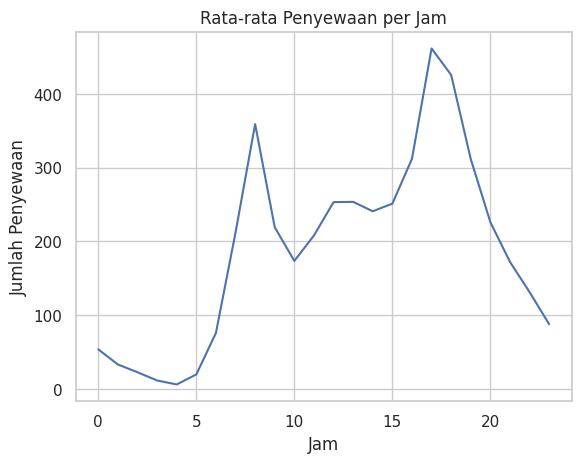

In [117]:
sns.lineplot(data=hourly_usage, x='hr', y='cnt')
plt.title("Rata-rata Penyewaan per Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Penyewaan")
plt.show()

**Insight**
- Jam 08.00 dan 17.00 merupakan waktu dengan permintaan tertinggi
- Perusahaan dapat menyesuaikan distribusi sepeda pada jam tersebut untuk menghindari kekurangan unit

### 5.2 Musim

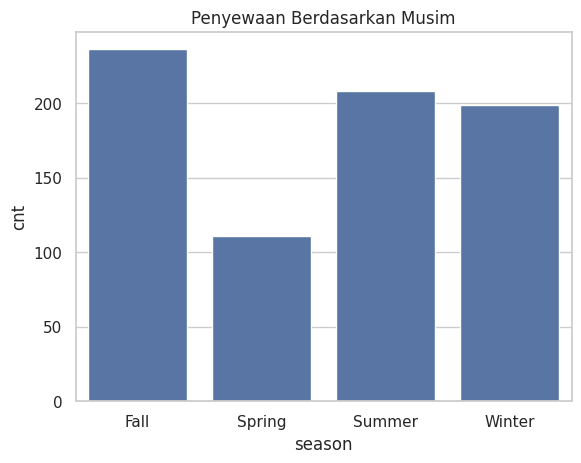

In [118]:
sns.barplot(data=season_usage, x='season', y='cnt')
plt.title("Penyewaan Berdasarkan Musim")
plt.show()

**Insight**
- Musim Fall memiliki permintaan tertinggi
- Strategi promosi dapat difokuskan pada musim dengan permintaan rendah seperti Spring

### 5.3 Cuaca

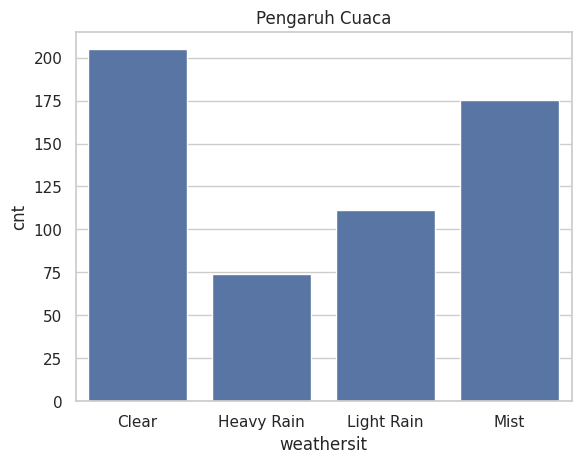

In [119]:
sns.barplot(data=weather_usage, x='weathersit', y='cnt')
plt.title("Pengaruh Cuaca")
plt.show()

**Insight**
- Penyewaan turun drastis saat hujan
- Perusahaan dapat memberikan insentif atau diskon saat kondisi cuaca buruk

### 5.4 Weekday vs Weekend

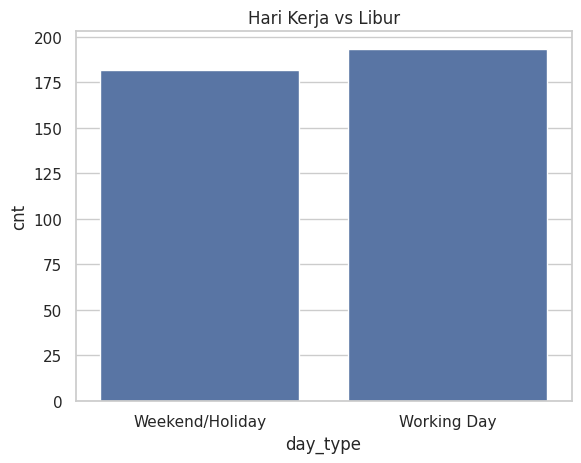

In [120]:
sns.barplot(data=day_type_usage, x='day_type', y='cnt')
plt.title("Hari Kerja vs Libur")
plt.show()

**Insight**
- Penggunaan lebih tinggi pada hari kerja
- Menunjukkan ketergantungan pada sepeda sebagai transportasi rutin

## 6. Analisis Lanjutan

### 6.1 RFM Analysis

In [121]:
rfm_df = hour_df.groupby('season').agg({
    'dteday': lambda x: (hour_df['dteday'].max() - x.max()).days,
    'cnt': ['count', 'sum']
})

rfm_df.columns = ['Recency', 'Frequency', 'Monetary']
rfm_df = rfm_df.reset_index()

rfm_df

,season,Recency,Frequency,Monetary
0,Fall,100,4496,1061129
1,Spring,0,4242,471348
2,Summer,194,4409,918589
3,Winter,11,4232,841613


### 6.2 Clustering (Manual Binning)

In [122]:
hour_df['usage_level'] = pd.cut(
    hour_df['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

cluster_usage = hour_df['usage_level'].value_counts().reset_index()
cluster_usage.columns = ['Usage Level', 'Count']

cluster_usage

,Usage Level,Count
0,Low,13990
1,Medium,2919
2,High,470


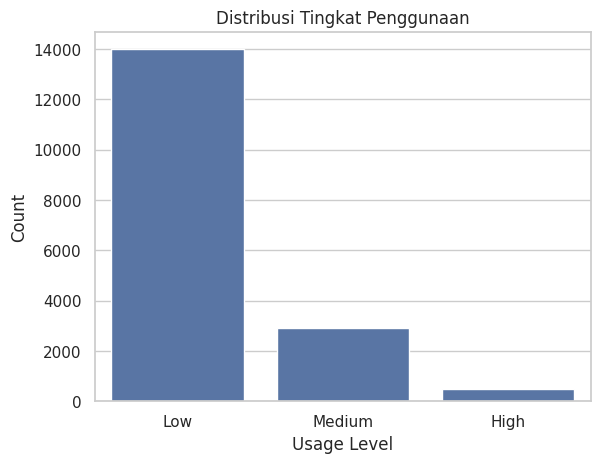

In [123]:
sns.barplot(data=cluster_usage, x='Usage Level', y='Count')
plt.title("Distribusi Tingkat Penggunaan")
plt.show()

**Insight:**
- Penggunaan sepeda tidak merata sepanjang waktu, melainkan terkonsentrasi pada periode tertentu (peak hours dan musim tertentu seperti Fall).
- Nilai Monetary yang tinggi pada musim Fall didukung oleh frekuensi penggunaan yang konsisten serta adanya periode High usage yang signifikan.


## 7. Conclusion

- Pertanyaan 1
  - Puncak penggunaan terjadi pada jam 08.00 dan 17.00
  - Musim Fall memiliki rata-rata penyewaan tertinggi
  - Hari kerja menunjukkan aktivitas lebih tinggi dibandingkan akhir pekan
- Kesimpulan:
  - Penggunaan sepeda didominasi oleh kebutuhan transportasi harian (commuting)

- Pertanyaan 2
  - Cuaca cerah meningkatkan penyewaan secara signifikan
  - Hujan menurunkan penyewaan hingga lebih dari setengahnya
  - Suhu memiliki pengaruh positif terhadap jumlah penyewaan
  - Hari kerja lebih tinggi dibanding hari libur
- Kesimpulan:
  - Permintaan sepeda dipengaruhi oleh faktor lingkungan dan kebutuhan mobilitas

- Rekomendasi
  - Optimalkan distribusi sepeda pada jam sibuk
  - Gunakan data cuaca untuk prediksi permintaan
  - Berikan promo pada kondisi cuaca buruk
  - Fokus pengembangan layanan di area commuting